Here we check how the network influences the behaviour of the automaton. We load all networks that are also used by Lucas in the LLNA papers.

# General remarks

- The behaviour depends on the network. It is _not_ the case that rule $\phi^9_{488,464}$ always leads to a 'totalitarian' outcome.
- We should figure out whether this particular rule is good at network identification
- We should experiment with other self-equivalent rules that qualify, and see whether some of these _do_ lead to a homogeneous outcome.

In [1]:
# standard preamble for the Notebooks I use
import torch as tc
import igraph as ig
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import rcParams

# Enable LaTeX and set Times New Roman as the font
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: Use LaTeX packages
})

from tqdm import tqdm

import sys, os
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.append(parent_dir)

# compact saving of data
import h5py

from src.automata import LLNA
from src.simulation import *
from src.rules import binary_indices, return_equivalent_rule, get_nonequiv_rules, return_life_like_dict
from src.networks import create_2d_torus_lattice, watts_strogatz_rewire
from src.analysis import median_and_percentiles_over_ensemble, mean_field_dens_propagation, derrida_map_analytical, hamming_weight, boolean_sens, mean_field_slope

%load_ext autoreload
%autoreload 2

In [2]:
# load additional classes
import numpy as np
import torch as tc
import torch_geometric as tg
import torch.nn.functional as F

# from torch_sparse import SparseTensor
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as GraphDataLoader
from torch.utils.data import Dataset, DataLoader, Subset, RandomSampler, WeightedRandomSampler
from sklearn.model_selection import train_test_split

from typing import Union

#===========================================================
class DiscreteStateNetwork(Data):
    def __init__(self, edge_index:list=[[0], [0]], y:int=0, num_states:int=2, num_inits:int=1, *args, **kwargs):
        """
        `edge_index`: indices of the edges (i,j) in the form [[i1, ... im], [j1, ... jm]]
        `y`: integer code of the respective class
        `num_states`: the number of states to randomly generate the state vector (default: binary network)
        `num_inits`: the number of different initial configurations to generate, also affects the y vector (expansion)
        """
        num_nodes = np.max(edge_index) + 1
        super(DiscreteStateNetwork, self).__init__(
            edge_index = tc.tensor(edge_index, dtype=tc.long), # shape of [2, |E|]
            node_state = tc.randint(0, num_states, (num_nodes, num_inits)).float(), # shape of [|V|, L]
            y = tc.tensor(y).expand(num_inits), # shape of [L]
            batch = tc.zeros(num_nodes), # shape of [|V|]
            *args, **kwargs
        )

    def unpack(self):
        return tuple([self.edge_index, self.node_state.T, self.batch, self.y])


#===========================================================
class DiscreteStateNetworkDataset(Dataset):
    def __init__(self, network_collection, device:str='cpu', *args, **kwargs):
        classes, labels = np.unique(network_collection['label'], return_inverse=True)
        for G in network_collection['graph']:
            G.data = G.data.as_directed()
        self.data = [ 
            DiscreteStateNetwork(np.transpose(G.edges()), y, *args, **kwargs) 
            for (G, y) in zip(network_collection['graph'], labels)
        ]
        self.classes = tuple(classes)
        self.device = device

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx:int):
        return self.data[idx].to(self.device)

    @property
    def labels(self):
        return tc.stack([ G.y for G in self ], 0)

    def _random_loader(self, indices, num_samples:Union[int,float]=0, balance:bool=False, *args, **kwargs):
        subset  = Subset(self, indices)
        if isinstance(num_samples, float):
            num_samples = int(num_samples * len(subset))
        num_samples = min(num_samples, len(subset))
        if not num_samples:
            sampler = None
        elif not balance:
            sampler = RandomSampler(subset, False, num_samples)
        else:
            labels = self.labels[indices, 0]
            chances = 1.0 / np.bincount(labels)
            weights = chances[labels]
            sampler = WeightedRandomSampler(weights, num_samples, True)
        loader = GraphDataLoader(subset, sampler=sampler, *args, **kwargs)
        return loader

    def _index_split(self, pool:list, proportion:list, stratify:bool, seed:int=None):
        indices = []
        taken = 0.0
        for p in proportion:
            percent = p / (1.0 - taken)
            taken += p
            if taken >= 1.0:
                break
            elif percent == 0:
                indices.append([])
                continue
            strat = self.labels[pool].to('cpu') if stratify else None
            selected, pool = train_test_split(pool, train_size=percent, stratify=strat, random_state=seed)
            indices.append(selected)
        indices.append(pool)
        return indices

    def split(self, training:float, validation:float=0, stratify:bool=True, folds:int=0, pool:list=None, sampling:tuple=(0,0,0), 
                repeat:int=0, seed:int=None, *args, **kwargs):
        if 'batch_size' not in kwargs: # temporary, it should be in the named param list
            kwargs['batch_size'] = 1
        if repeat > 0:
            if seed is None:
                seed = [None]*repeat
            return [ 
                self.split(training, validation, stratify, folds, pool, sampling, repeat=0, seed=seed[i], *args, **kwargs) 
                for i in range(repeat) 
            ]
        if pool is None:
            pool = np.arange(len(self))
        if 'batch_size' not in kwargs:
            kwargs['batch_size'] = None
        if folds in [0, 1]:
            (tr_idx, vl_idx, te_idx) = self._index_split(pool, [training, validation], stratify, seed)
            loaders = {
                'train': self._random_loader(tr_idx, sampling[0], *args, **kwargs), 
                'valid': self._random_loader(vl_idx, sampling[1], *args, **kwargs), 
                'test': self._random_loader(te_idx, sampling[-1], *args, **kwargs) 
            }
            return loaders if not folds else [loaders]
        else:
            folds_idx = self._index_split(pool, [1.0/folds] * (folds-1), stratify, seed)
            dataloaders = []
            for te_idx in folds_idx:
                scale = 1 / (training + validation)
                subpool = list(set(pool) - set(te_idx))
                if validation > 0:
                    (tr_idx, vl_idx) = self._index_split(subpool, [training*scale, validation*scale], stratify, seed)
                else:
                    (tr_idx, vl_idx) = (subpool, [])
                dataloaders.append({
                    'train': self._random_loader(tr_idx, sampling[0], *args, **kwargs),
                    'valid': self._random_loader(vl_idx, sampling[1], *args, **kwargs), 
                    'test': self._random_loader(te_idx, sampling[-1], *args, **kwargs)
                })
            return dataloaders

# Load our favourite local update rule

This rule is equivalent to itself.


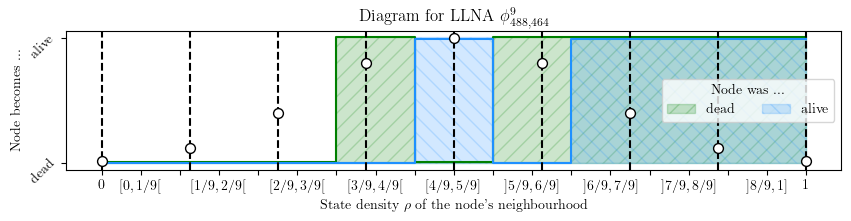

In [10]:
resolution = 9
beta, sigma = (488, 464)
B_set = binary_indices(beta)
S_set = binary_indices(sigma)

# this rule is equivalent to itself
beta_equiv, sigma_equiv = return_equivalent_rule(resolution, B_set, S_set, return_decimals=True)
if (beta, sigma) == (beta_equiv, sigma_equiv):
    print("This rule is equivalent to itself.")

model = LLNA(resolution, B_set, S_set, iso=True)
model.diagram(degree=8, plot_dist=True)

def init_config_with_dens(N, dens):
    # defines a random initial configuration with a fixed state density
    s0 = np.zeros(N, dtype=int)
    s0[:np.round(dens*N).astype(int)] = 1.
    np.random.shuffle(s0)
    return s0

# Load various graphs from the database

# 1. Synthetic graphs

In [12]:
#EE import classes from submodule

## fix path
import sys, os
# path to src
sys.path.append(os.path.abspath(".."))
# path to submodule
sys.path.append(os.path.abspath("../src/network_analysis"))

## get classes
from src.network_analysis.lib.datasources import SyntheticNetworks #, KeggMetabolicNetworks

### 1.1 Classic networks

In [ ]:
# load dataframe with networks
base_folder = "..\\src\\network_analysis\\data"
SyntheticNetworks.setup(base_folder=base_folder, random_seed=99999, loader_mode='full')

networks_classic = SyntheticNetworks.classic(samples_per_label=100, balanced=True)


synthetic:classic


[watts-strogatz]              : 100%|█████████| 100/100 [00:50<00:00,  1.99it/s]


In [96]:
grouped = networks_classic.groupby('label')
keys = networks_classic.label.unique()
networks_dict = {key: group for key, group in grouped}

dataset_dict = {key: DiscreteStateNetworkDataset(networks_dict[key], num_states=2, num_inits=1) for key in keys}

In [97]:
RESET=False
if RESET:
    final_config_dict = {}
T=200

for label in keys:
    print(f"Working with label {label} ...")

    final_config_mean_array = []
    dict_length = len(dataset_dict[label])
    for G in tqdm(dataset_dict[label], total=dict_length):
        # load graph and initial configuration  
        (E, h, _, y) = G.unpack()
        edges_classic = E.numpy().T
        num_nodes = h.shape[1]
        # graph_classic = ig.Graph(n=num_nodes, edges=edges_classic)
        # init_config = h # these are not at an average state of exactly 0.5
        init_config = tc.tensor(init_config_with_dens(num_nodes, 0.5)[np.newaxis,:]) # this is a random init config with density 0.5
        configs = model.forward(E, init_config, T=T)
        # find mean of final configuration
        final_config_mean = np.mean(configs[0,-1].numpy())
        final_config_mean_array.append(final_config_mean)
    final_config_mean_array = np.array(final_config_mean_array)
    
    # add to dict
    final_config_dict[label] = final_config_mean_array

Working with label barabasi-albert ...


100%|██████████| 100/100 [01:06<00:00,  1.51it/s]


Working with label erdos-renyi ...


100%|██████████| 100/100 [01:04<00:00,  1.54it/s]


Working with label geographic ...


100%|██████████| 100/100 [01:02<00:00,  1.60it/s]


Working with label watts-strogatz ...


100%|██████████| 100/100 [01:00<00:00,  1.67it/s]


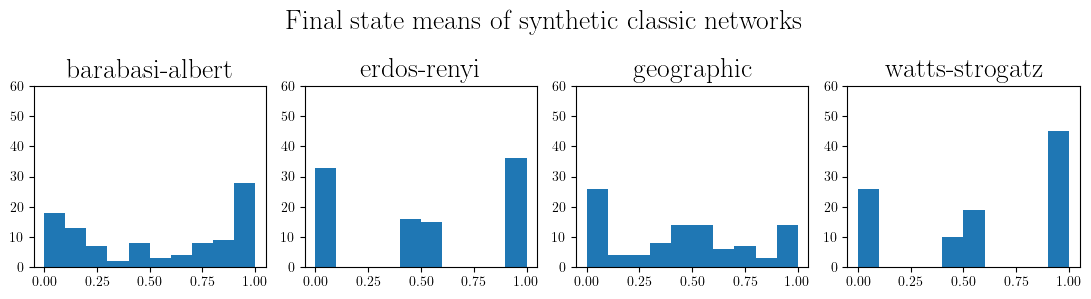

In [ ]:
fig, axs = plt.subplots(1,4,figsize=(11,3))
bins = np.linspace(0,1,11)
fontsize=20

for ax, label in zip(axs, keys):
    ax.hist(final_config_dict[label], bins=bins)
    ax.set_title(f"{label}", fontsize=fontsize)
    ax.set_ylim([0,60])

fig.suptitle("Final state means of synthetic classic networks", fontsize=fontsize)

plt.tight_layout()
plt.savefig(f"final-states_rule{model.__str__()}_synthetic-classic-networks.pdf", bbox_inches='tight')

### 1.2 Scalefree networks

In [51]:
# load dataframe with networks
base_folder = "..\\src\\network_analysis\\data"
SyntheticNetworks.setup(base_folder=base_folder, random_seed=99999, loader_mode='full')

networks_scalefree = SyntheticNetworks.scalefree(samples_per_label=100, balanced=True)


synthetic:scalefree


[scale-free nlin (2.0)]       : 100%|█████████| 100/100 [00:21<00:00,  4.60it/s]


In [ ]:
grouped = networks_scalefree.groupby('label')
keys = networks_scalefree.label.unique()
networks_dict = {key: group for key, group in grouped}

dataset_dict = {key: DiscreteStateNetworkDataset(networks_dict[key], num_states=2, num_inits=1) for key in keys}

Run from initial configuration with exactly the same number of 0s and 1s.

In [ ]:
RESET=False
if RESET:
    final_config_dict = {}
T=200

for label in keys:
    print(f"Working with label {label} ...")

    final_config_mean_array = []
    dict_length = len(dataset_dict[label])
    for G in tqdm(dataset_dict[label], total=dict_length):
        # load graph and initial configuration  
        (E, h, _, y) = G.unpack()
        edges_scalefree = E.numpy().T
        num_nodes = h.shape[1]
        # graph_scalefree = ig.Graph(n=num_nodes, edges=edges_scalefree)
        # init_config = h # these are not at an average state of exactly 0.5
        init_config = tc.tensor(init_config_with_dens(num_nodes, 0.5)[np.newaxis,:]) # this is a random init config with density 0.5
        configs = model.forward(E, init_config, T=T)
        # find mean of final configuration
        final_config_mean = np.mean(configs[0,-1].numpy())
        final_config_mean_array.append(final_config_mean)
    final_config_mean_array = np.array(final_config_mean_array)
    
    # add to dict
    final_config_dict[label] = final_config_mean_array

Working with label scale-free nlin (2.0) ...


100%|██████████| 100/100 [00:55<00:00,  1.82it/s]


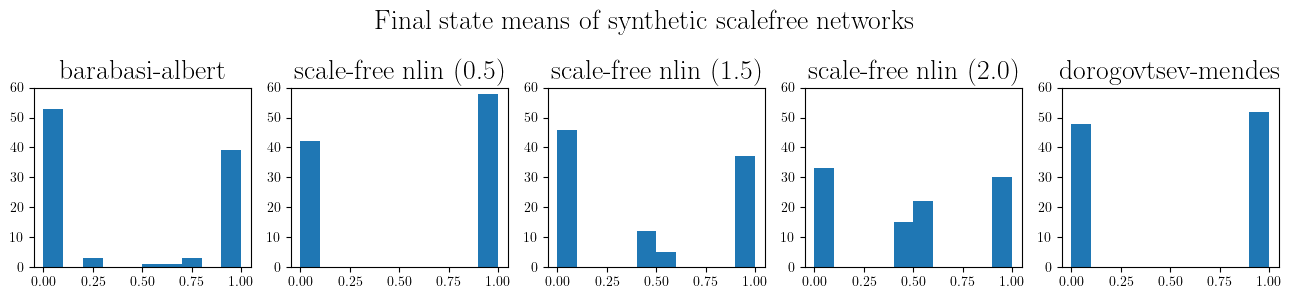

In [93]:
fig, axs = plt.subplots(1,5,figsize=(13,3))
bins = np.linspace(0,1,11)
fontsize=20

for ax, label in zip(axs, keys):
    ax.hist(final_config_dict[label], bins=bins)
    ax.set_title(f"{label}", fontsize=fontsize)
    ax.set_ylim([0,60])

fig.suptitle("Final state means of synthetic scalefree networks", fontsize=fontsize)

plt.tight_layout()
plt.savefig(f"final-states_rule{model.__str__()}_synthetic-scalefree-networks.pdf", bbox_inches='tight')

### 1.3 Noise = 10 percent

In [99]:
# load dataframe with networks
base_folder = "..\\src\\network_analysis\\data"
SyntheticNetworks.setup(base_folder=base_folder, random_seed=99999, loader_mode='full')

networks_noise10 = SyntheticNetworks.noise10(samples_per_label=100, balanced=True)


synthetic:noise=10


[watts-strogatz]              : 100%|█████████| 100/100 [00:28<00:00,  3.57it/s]


In [100]:
grouped = networks_noise10.groupby('label')
keys = networks_noise10.label.unique()
networks_dict = {key: group for key, group in grouped}

dataset_dict = {key: DiscreteStateNetworkDataset(networks_dict[key], num_states=2, num_inits=1) for key in keys}

In [101]:
RESET=False
if RESET:
    final_config_dict = {}
T=200

for label in keys:
    print(f"Working with label {label} ...")

    final_config_mean_array = []
    dict_length = len(dataset_dict[label])
    for G in tqdm(dataset_dict[label], total=dict_length):
        # load graph and initial configuration  
        (E, h, _, y) = G.unpack()
        edges_noise10 = E.numpy().T
        num_nodes = h.shape[1]
        # graph_noise10 = ig.Graph(n=num_nodes, edges=edges_noise10)
        # init_config = h # these are not at an average state of exactly 0.5
        init_config = tc.tensor(init_config_with_dens(num_nodes, 0.5)[np.newaxis,:]) # this is a random init config with density 0.5
        configs = model.forward(E, init_config, T=T)
        # find mean of final configuration
        final_config_mean = np.mean(configs[0,-1].numpy())
        final_config_mean_array.append(final_config_mean)
    final_config_mean_array = np.array(final_config_mean_array)
    
    # add to dict
    final_config_dict[label] = final_config_mean_array

Working with label barabasi-albert ...


100%|██████████| 100/100 [00:58<00:00,  1.70it/s]


Working with label scale-free nlin (0.5) ...


100%|██████████| 100/100 [01:19<00:00,  1.26it/s]


Working with label scale-free nlin (1.5) ...


...

100%|██████████| 100/100 [01:07<00:00,  1.49it/s]


Working with label geographic ...


100%|██████████| 100/100 [01:04<00:00,  1.56it/s]


Working with label watts-strogatz ...


100%|██████████| 100/100 [01:01<00:00,  1.62it/s]


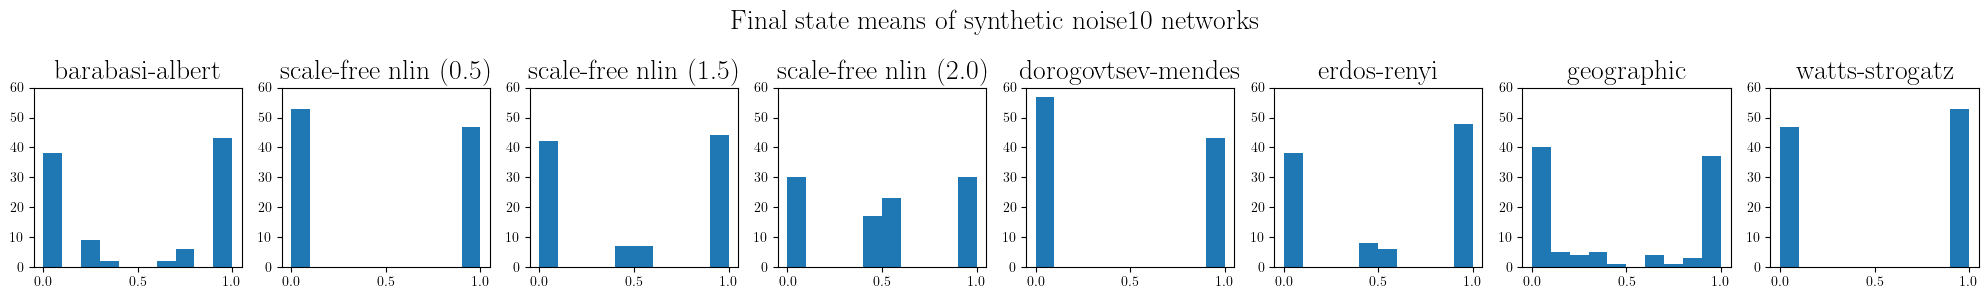

In [103]:
fig, axs = plt.subplots(1,8,figsize=(20,3))
bins = np.linspace(0,1,11)
fontsize=20

for ax, label in zip(axs, keys):
    ax.hist(final_config_dict[label], bins=bins)
    ax.set_title(f"{label}", fontsize=fontsize)
    ax.set_ylim([0,60])

fig.suptitle("Final state means of synthetic noise10 networks", fontsize=fontsize)

plt.tight_layout()
plt.savefig(f"final-states_rule{model.__str__()}_synthetic-noise10-networks.pdf", bbox_inches='tight')

# 2. Metabolic networks

In [4]:
#EE import classes from submodule

## fix path
import sys, os
# path to src
sys.path.append(os.path.abspath(".."))
# path to submodule
sys.path.append(os.path.abspath("../src/network_analysis"))

## get classes
from src.network_analysis.lib.datasources import KeggMetabolicNetworks

### 2.1 Actinobacteria

In [7]:
# load dataframe with networks
base_folder = "..\\src\\network_analysis\\data"
KeggMetabolicNetworks.setup(base_folder=base_folder, random_seed=99999, loader_mode='full')

networks_actinobac = KeggMetabolicNetworks.actinobac(samples_per_label=100, balanced=True)


kegg-metabolic:actinobacteria


[Streptomyces]                : 100%|██████████| 63/63 [00:00<00:00, 391.11it/s]


In [8]:
grouped = networks_actinobac.groupby('label')
keys = networks_actinobac.label.unique()
networks_dict = {key: group for key, group in grouped}

dataset_dict = {key: DiscreteStateNetworkDataset(networks_dict[key], num_states=2, num_inits=1) for key in keys}

In [12]:
RESET=False
if RESET:
    final_config_dict = {}
T=200

for label in keys:
    print(f"Working with label {label} ...")

    final_config_mean_array = []
    dict_length = len(dataset_dict[label])
    for G in tqdm(dataset_dict[label], total=dict_length):
        # load graph and initial configuration  
        (E, h, _, y) = G.unpack()
        edges_actinobac = E.numpy().T
        num_nodes = h.shape[1]
        # graph_actinobac = ig.Graph(n=num_nodes, edges=edges_actinobac)
        # init_config = h # these are not at an average state of exactly 0.5
        init_config = tc.tensor(init_config_with_dens(num_nodes, 0.5)[np.newaxis,:]) # this is a random init config with density 0.5
        configs = model.forward(E, init_config, T=T)
        # find mean of final configuration
        final_config_mean = np.mean(configs[0,-1].numpy())
        final_config_mean_array.append(final_config_mean)
    final_config_mean_array = np.array(final_config_mean_array)
    
    # add to dict
    final_config_dict[label] = final_config_mean_array

Working with label Corynebacterium ...


100%|██████████| 63/63 [00:19<00:00,  3.20it/s]


Working with label Mycobacterium ...


100%|██████████| 63/63 [00:21<00:00,  2.96it/s]


Working with label Streptomyces ...


100%|██████████| 63/63 [00:20<00:00,  3.09it/s]


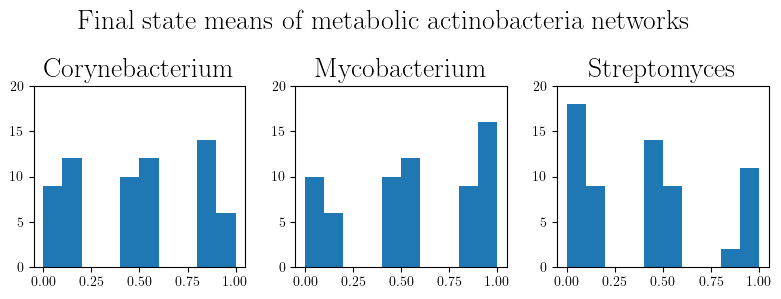

In [14]:
fig, axs = plt.subplots(1,3,figsize=(8,3))
bins = np.linspace(0,1,11)
fontsize=20

for ax, label in zip(axs, keys):
    ax.hist(final_config_dict[label], bins=bins)
    ax.set_title(f"{label}", fontsize=fontsize)
    ax.set_ylim([0,20])

fig.suptitle("Final state means of metabolic actinobacteria networks", fontsize=fontsize)

plt.tight_layout()
plt.savefig(f"final-states_rule{model.__str__()}_metabolic-actinobac-networks.pdf", bbox_inches='tight')

### 2.2 Animals

In [31]:
# load dataframe with networks
base_folder = "..\\src\\network_analysis\\data"
KeggMetabolicNetworks.setup(base_folder=base_folder, random_seed=99999, loader_mode='full')

networks_animals = KeggMetabolicNetworks.animals(samples_per_label=100, balanced=True)


kegg-metabolic:animals


[mammals]                     : 100%|███████████| 16/16 [00:00<00:00, 46.71it/s]


In [32]:
grouped = networks_animals.groupby('label')
keys = networks_animals.label.unique()
networks_dict = {key: group for key, group in grouped}

dataset_dict = {key: DiscreteStateNetworkDataset(networks_dict[key], num_states=2, num_inits=1) for key in keys}
print(keys)

['birds' 'fishes' 'insects' 'mammals']


In [33]:
RESET=False
if RESET:
    final_config_dict = {}
T=200

for label in keys:
    print(f"Working with label {label} ...")

    final_config_mean_array = []
    dict_length = len(dataset_dict[label])
    for G in tqdm(dataset_dict[label], total=dict_length):
        # load graph and initial configuration  
        (E, h, _, y) = G.unpack()
        edges_animals = E.numpy().T
        num_nodes = h.shape[1]
        # graph_animals = ig.Graph(n=num_nodes, edges=edges_animals)
        # init_config = h # these are not at an average state of exactly 0.5
        init_config = tc.tensor(init_config_with_dens(num_nodes, 0.5)[np.newaxis,:]) # this is a random init config with density 0.5
        configs = model.forward(E, init_config, T=T)
        # find mean of final configuration
        final_config_mean = np.mean(configs[0,-1].numpy())
        final_config_mean_array.append(final_config_mean)
    final_config_mean_array = np.array(final_config_mean_array)
    
    # add to dict
    final_config_dict[label] = final_config_mean_array

Working with label birds ...


100%|██████████| 16/16 [00:05<00:00,  2.82it/s]


Working with label fishes ...


100%|██████████| 16/16 [00:05<00:00,  2.80it/s]


Working with label insects ...


100%|██████████| 16/16 [00:05<00:00,  3.08it/s]


Working with label mammals ...


100%|██████████| 16/16 [00:05<00:00,  2.84it/s]


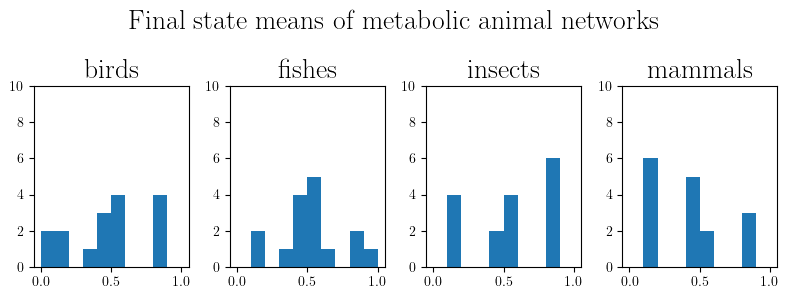

In [34]:
fig, axs = plt.subplots(1,len(keys),figsize=(8,3))
bins = np.linspace(0,1,11)
fontsize=20

for ax, label in zip(axs, keys):
    ax.hist(final_config_dict[label], bins=bins)
    ax.set_title(f"{label}", fontsize=fontsize)
    ax.set_ylim([0,10])

fig.suptitle("Final state means of metabolic animal networks", fontsize=fontsize)

plt.tight_layout()
plt.savefig(f"final-states_rule{model.__str__()}_metabolic-animal-networks.pdf", bbox_inches='tight')

### 2.3 Firmicutes Bacillis

In [24]:
# load dataframe with networks
base_folder = "..\\src\\network_analysis\\data"
KeggMetabolicNetworks.setup(base_folder=base_folder, random_seed=99999, loader_mode='full')

networks_fbacillis = KeggMetabolicNetworks.fbacillis(samples_per_label=100, balanced=True)


kegg-metabolic:firmicutes-bacillis


[Streptococcus]               : 100%|███████████| 86/86 [00:01<00:00, 61.52it/s]


In [25]:
grouped = networks_fbacillis.groupby('label')
keys = networks_fbacillis.label.unique()
networks_dict = {key: group for key, group in grouped}

dataset_dict = {key: DiscreteStateNetworkDataset(networks_dict[key], num_states=2, num_inits=1) for key in keys}
print(keys)

['Bacillus' 'Lactobacillus' 'Staphylococcus' 'Streptococcus']


In [26]:
RESET=False
if RESET:
    final_config_dict = {}
T=200

for label in keys:
    print(f"Working with label {label} ...")

    final_config_mean_array = []
    dict_length = len(dataset_dict[label])
    for G in tqdm(dataset_dict[label], total=dict_length):
        # load graph and initial configuration  
        (E, h, _, y) = G.unpack()
        edges_fbacillis = E.numpy().T
        num_nodes = h.shape[1]
        # graph_fbacillis = ig.Graph(n=num_nodes, edges=edges_fbacillis)
        # init_config = h # these are not at an average state of exactly 0.5
        init_config = tc.tensor(init_config_with_dens(num_nodes, 0.5)[np.newaxis,:]) # this is a random init config with density 0.5
        configs = model.forward(E, init_config, T=T)
        # find mean of final configuration
        final_config_mean = np.mean(configs[0,-1].numpy())
        final_config_mean_array.append(final_config_mean)
    final_config_mean_array = np.array(final_config_mean_array)
    
    # add to dict
    final_config_dict[label] = final_config_mean_array

Working with label Bacillus ...


100%|██████████| 86/86 [00:29<00:00,  2.92it/s]


Working with label Lactobacillus ...


100%|██████████| 86/86 [00:25<00:00,  3.39it/s]


Working with label Staphylococcus ...


100%|██████████| 86/86 [00:24<00:00,  3.44it/s]


Working with label Streptococcus ...


100%|██████████| 86/86 [00:23<00:00,  3.69it/s]


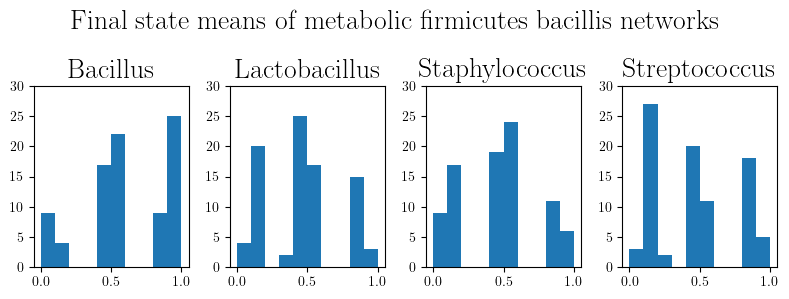

In [30]:
fig, axs = plt.subplots(1,len(keys),figsize=(8,3))
bins = np.linspace(0,1,11)
fontsize=20

for ax, label in zip(axs, keys):
    ax.hist(final_config_dict[label], bins=bins)
    ax.set_title(f"{label}", fontsize=fontsize)
    ax.set_ylim([0,30])

fig.suptitle("Final state means of metabolic firmicutes bacillis networks", fontsize=fontsize)

plt.tight_layout()
plt.savefig(f"final-states_rule{model.__str__()}_metabolic-fbacillis-networks.pdf", bbox_inches='tight')

### 2.4 Fungi

In [36]:
# load dataframe with networks
base_folder = "..\\src\\network_analysis\\data"
KeggMetabolicNetworks.setup(base_folder=base_folder, random_seed=99999, loader_mode='full')

networks_fungi = KeggMetabolicNetworks.fungi(samples_per_label=100, balanced=True)


kegg-metabolic:fungi


[sordariomycetes]             : 100%|██████████| 17/17 [00:00<00:00, 292.93it/s]


In [37]:
grouped = networks_fungi.groupby('label')
keys = networks_fungi.label.unique()
networks_dict = {key: group for key, group in grouped}

dataset_dict = {key: DiscreteStateNetworkDataset(networks_dict[key], num_states=2, num_inits=1) for key in keys}
print(keys)

['basidiomycetes' 'eurotiomycetes' 'saccharomycetes' 'sordariomycetes']


In [38]:
RESET=False
if RESET:
    final_config_dict = {}
T=200

for label in keys:
    print(f"Working with label {label} ...")

    final_config_mean_array = []
    dict_length = len(dataset_dict[label])
    for G in tqdm(dataset_dict[label], total=dict_length):
        # load graph and initial configuration  
        (E, h, _, y) = G.unpack()
        edges_fungi = E.numpy().T
        num_nodes = h.shape[1]
        # graph_fungi = ig.Graph(n=num_nodes, edges=edges_fungi)
        # init_config = h # these are not at an average state of exactly 0.5
        init_config = tc.tensor(init_config_with_dens(num_nodes, 0.5)[np.newaxis,:]) # this is a random init config with density 0.5
        configs = model.forward(E, init_config, T=T)
        # find mean of final configuration
        final_config_mean = np.mean(configs[0,-1].numpy())
        final_config_mean_array.append(final_config_mean)
    final_config_mean_array = np.array(final_config_mean_array)
    
    # add to dict
    final_config_dict[label] = final_config_mean_array

Working with label basidiomycetes ...


100%|██████████| 17/17 [00:06<00:00,  2.65it/s]


Working with label eurotiomycetes ...


100%|██████████| 17/17 [00:06<00:00,  2.47it/s]


Working with label saccharomycetes ...


100%|██████████| 17/17 [00:05<00:00,  2.84it/s]


Working with label sordariomycetes ...


100%|██████████| 17/17 [00:05<00:00,  3.04it/s]


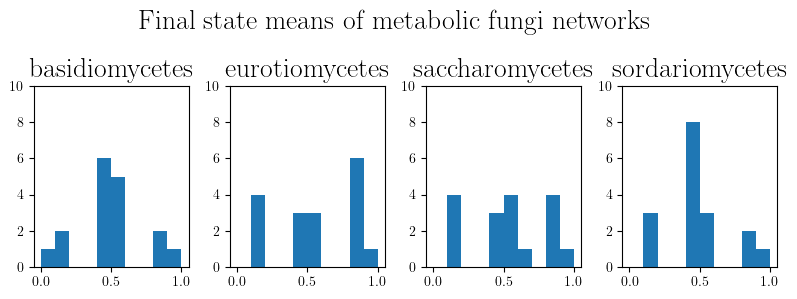

In [40]:
fig, axs = plt.subplots(1,len(keys),figsize=(8,3))
bins = np.linspace(0,1,11)
fontsize=20

for ax, label in zip(axs, keys):
    ax.hist(final_config_dict[label], bins=bins)
    ax.set_title(f"{label}", fontsize=fontsize)
    ax.set_ylim([0,10])

fig.suptitle("Final state means of metabolic fungi networks", fontsize=fontsize)

plt.tight_layout()
plt.savefig(f"final-states_rule{model.__str__()}_metabolic-fungi-networks.pdf", bbox_inches='tight')

### 2.5 Kingdom

In [41]:
# load dataframe with networks
base_folder = "..\\src\\network_analysis\\data"
KeggMetabolicNetworks.setup(base_folder=base_folder, random_seed=99999, loader_mode='full')

networks_kingdom = KeggMetabolicNetworks.kingdom(samples_per_label=100, balanced=True)


kegg-metabolic:kingdom


[protist]                     : 100%|███████████| 49/49 [00:00<00:00, 71.91it/s]


In [42]:
grouped = networks_kingdom.groupby('label')
keys = networks_kingdom.label.unique()
networks_dict = {key: group for key, group in grouped}

dataset_dict = {key: DiscreteStateNetworkDataset(networks_dict[key], num_states=2, num_inits=1) for key in keys}
print(keys)

['animals' 'fungi' 'plants' 'protist']


In [ ]:
RESET=False
if RESET:
    final_config_dict = {}
T=200

for label in keys:
    print(f"Working with label {label} ...")

    final_config_mean_array = []
    dict_length = len(dataset_dict[label])
    for G in tqdm(dataset_dict[label], total=dict_length):
        # load graph and initial configuration  
        (E, h, _, y) = G.unpack()
        edges_kingdom = E.numpy().T
        num_nodes = h.shape[1]
        # graph_kingdom = ig.Graph(n=num_nodes, edges=edges_kingdom)
        # init_config = h # these are not at an average state of exactly 0.5
        init_config = tc.tensor(init_config_with_dens(num_nodes, 0.5)[np.newaxis,:]) # this is a random init config with density 0.5
        configs = model.forward(E, init_config, T=T)
        # find mean of final configuration
        final_config_mean = np.mean(configs[0,-1].numpy())
        final_config_mean_array.append(final_config_mean)
    final_config_mean_array = np.array(final_config_mean_array)
    
    # add to dict
    final_config_dict[label] = final_config_mean_array

Working with label animals ...


100%|██████████| 49/49 [00:19<00:00,  2.48it/s]


Working with label fungi ...


100%|██████████| 49/49 [00:16<00:00,  2.96it/s]


Working with label plants ...


100%|██████████| 49/49 [00:16<00:00,  2.89it/s]


Working with label protist ...


100%|██████████| 49/49 [00:14<00:00,  3.43it/s]


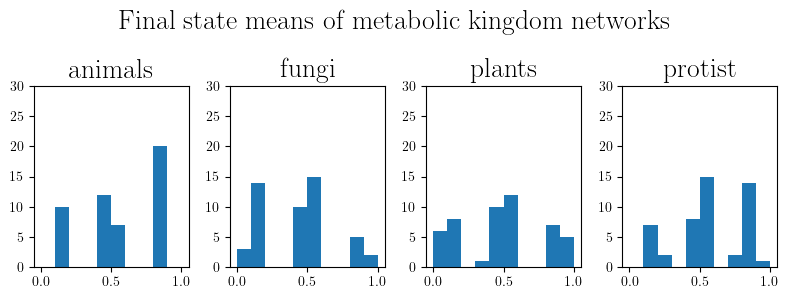

In [47]:
fig, axs = plt.subplots(1,len(keys),figsize=(2*len(keys),3))
bins = np.linspace(0,1,11)
fontsize=20

for ax, label in zip(axs, keys):
    ax.hist(final_config_dict[label], bins=bins)
    ax.set_title(f"{label}", fontsize=fontsize)
    ax.set_ylim([0,30])

fig.suptitle("Final state means of metabolic kingdom networks", fontsize=fontsize)

plt.tight_layout()
plt.savefig(f"final-states_rule{model.__str__()}_metabolic-kingdom-networks.pdf", bbox_inches='tight')

### 2.6 Plant

In [48]:
# load dataframe with networks
base_folder = "..\\src\\network_analysis\\data"
KeggMetabolicNetworks.setup(base_folder=base_folder, random_seed=99999, loader_mode='full')

networks_plant = KeggMetabolicNetworks.plant(samples_per_label=100, balanced=True)


kegg-metabolic:plant


[monocots]                    : 100%|███████████| 11/11 [00:00<00:00, 56.41it/s]


In [49]:
grouped = networks_plant.groupby('label')
keys = networks_plant.label.unique()
networks_dict = {key: group for key, group in grouped}

dataset_dict = {key: DiscreteStateNetworkDataset(networks_dict[key], num_states=2, num_inits=1) for key in keys}
print(keys)

['eudicots' 'greenalgae' 'monocots']


In [50]:
RESET=False
if RESET:
    final_config_dict = {}
T=200

for label in keys:
    print(f"Working with label {label} ...")

    final_config_mean_array = []
    dict_length = len(dataset_dict[label])
    for G in tqdm(dataset_dict[label], total=dict_length):
        # load graph and initial configuration  
        (E, h, _, y) = G.unpack()
        edges_plant = E.numpy().T
        num_nodes = h.shape[1]
        # graph_plant = ig.Graph(n=num_nodes, edges=edges_plant)
        # init_config = h # these are not at an average state of exactly 0.5
        init_config = tc.tensor(init_config_with_dens(num_nodes, 0.5)[np.newaxis,:]) # this is a random init config with density 0.5
        configs = model.forward(E, init_config, T=T)
        # find mean of final configuration
        final_config_mean = np.mean(configs[0,-1].numpy())
        final_config_mean_array.append(final_config_mean)
    final_config_mean_array = np.array(final_config_mean_array)
    
    # add to dict
    final_config_dict[label] = final_config_mean_array

Working with label eudicots ...


100%|██████████| 11/11 [00:04<00:00,  2.46it/s]


Working with label greenalgae ...


100%|██████████| 11/11 [00:04<00:00,  2.42it/s]


Working with label monocots ...


100%|██████████| 11/11 [00:04<00:00,  2.47it/s]


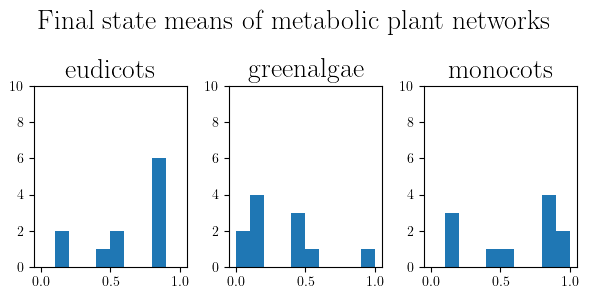

In [52]:
fig, axs = plt.subplots(1,len(keys),figsize=(2*len(keys),3))
bins = np.linspace(0,1,11)
fontsize=20

for ax, label in zip(axs, keys):
    ax.hist(final_config_dict[label], bins=bins)
    ax.set_title(f"{label}", fontsize=fontsize)
    ax.set_ylim([0,10])

fig.suptitle("Final state means of metabolic plant networks", fontsize=fontsize)

plt.tight_layout()
plt.savefig(f"final-states_rule{model.__str__()}_metabolic-plant-networks.pdf", bbox_inches='tight')

### 2.7 Protist

In [53]:
# load dataframe with networks
base_folder = "..\\src\\network_analysis\\data"
KeggMetabolicNetworks.setup(base_folder=base_folder, random_seed=99999, loader_mode='full')

networks_protist = KeggMetabolicNetworks.protist(samples_per_label=100, balanced=True)


kegg-metabolic:protist


[Stramenopiles]               : 100%|█████████████| 7/7 [00:00<00:00, 63.11it/s]


In [54]:
grouped = networks_protist.groupby('label')
keys = networks_protist.label.unique()
networks_dict = {key: group for key, group in grouped}

dataset_dict = {key: DiscreteStateNetworkDataset(networks_dict[key], num_states=2, num_inits=1) for key in keys}
print(keys)

['Alveolates' 'Amoebozoa' 'Euglenozoa' 'Stramenopiles']


In [55]:
RESET=False
if RESET:
    final_config_dict = {}
T=200

for label in keys:
    print(f"Working with label {label} ...")

    final_config_mean_array = []
    dict_length = len(dataset_dict[label])
    for G in tqdm(dataset_dict[label], total=dict_length):
        # load graph and initial configuration  
        (E, h, _, y) = G.unpack()
        edges_protist = E.numpy().T
        num_nodes = h.shape[1]
        # graph_protist = ig.Graph(n=num_nodes, edges=edges_protist)
        # init_config = h # these are not at an average state of exactly 0.5
        init_config = tc.tensor(init_config_with_dens(num_nodes, 0.5)[np.newaxis,:]) # this is a random init config with density 0.5
        configs = model.forward(E, init_config, T=T)
        # find mean of final configuration
        final_config_mean = np.mean(configs[0,-1].numpy())
        final_config_mean_array.append(final_config_mean)
    final_config_mean_array = np.array(final_config_mean_array)
    
    # add to dict
    final_config_dict[label] = final_config_mean_array

Working with label Alveolates ...


100%|██████████| 7/7 [00:02<00:00,  3.07it/s]


Working with label Amoebozoa ...


100%|██████████| 7/7 [00:02<00:00,  3.13it/s]


Working with label Euglenozoa ...


100%|██████████| 7/7 [00:02<00:00,  2.75it/s]


Working with label Stramenopiles ...


100%|██████████| 7/7 [00:02<00:00,  2.63it/s]


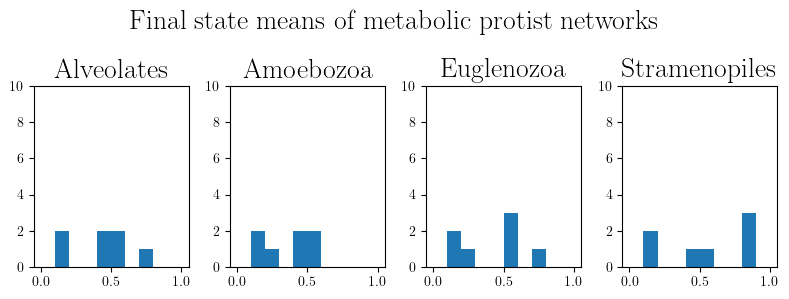

In [56]:
fig, axs = plt.subplots(1,len(keys),figsize=(2*len(keys),3))
bins = np.linspace(0,1,11)
fontsize=20

for ax, label in zip(axs, keys):
    ax.hist(final_config_dict[label], bins=bins)
    ax.set_title(f"{label}", fontsize=fontsize)
    ax.set_ylim([0,10])

fig.suptitle("Final state means of metabolic protist networks", fontsize=fontsize)

plt.tight_layout()
plt.savefig(f"final-states_rule{model.__str__()}_metabolic-protist-networks.pdf", bbox_inches='tight')